# Install Necessary Libraries

In [ ]:
%%capture

!pip install torch transformers chromadb datasets qwen-vl-utils hf_xet langchain-chroma langchain-core Pillow

In [ ]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("HF_TOKEN is not set. Please add it to Colab secrets.")

Successfully logged in to Hugging Face!


# (Optional) Install Flash Attention

Makes models run faster with less VRAM usage.

**Requires Ampere or newer GPU — T4 does NOT support Flash Attention.**
Skip this cell if running on T4. Use L4 or better for Flash Attention.

In [ ]:
!nvidia-smi

# Uncomment below ONLY if running on Ampere+ GPU (L4, A100, etc.) — NOT T4
# !pip install ninja
# !pip install flash-attn --no-build-isolation

Thu Mar 26 02:09:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Setup Paths to VDB and Qwen Scripts (the new VDB is in the shared folder)

In [ ]:
import os
import sys

from google.colab import drive
drive.mount('/content/drive')

# download this folder from my drive to get the scripts and the preprocessed VDB

# https://drive.google.com/drive/folders/1YOmGkaUuylhh3IjivjrnmoOyQxQ9KX3T?usp=sharing
# VDB is currently embedded with Qwen3VL-Embedding-2B

# when you mount your drive, adjust these paths accordingly to your drive
sys.path.append('/content/drive/MyDrive/colab/mcam/')
VDB_PATH = '/content/drive/MyDrive/colab/mcam/VDB'

Mounted at /content/drive


# Choose How Many Keywords to Find

In [ ]:
TERM_COUNT = 10

# Upload Your Art Images

Upload one or more images from your device. Each image will be processed through the pipeline.
You can also optionally provide a title and media/support description for each piece.

Select one or more image files to upload:


Saving ENDFIELD_SHARE_1771036361.png to ENDFIELD_SHARE_1771036361.png
  Loaded: ENDFIELD_SHARE_1771036361.png (1920x1288)


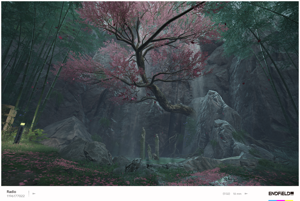


1 image(s) ready for processing.


In [ ]:
from google.colab import files
from PIL import Image
from io import BytesIO
import IPython.display

# Upload images from your device
print("Select one or more image files to upload:")
uploaded = files.upload()

# Store uploaded images for processing
uploaded_images = {}
for filename, content in uploaded.items():
    img = Image.open(BytesIO(content))
    # Save to /content so the Qwen model can read it as a file path
    save_path = f"/content/{filename}"
    img.save(save_path)
    uploaded_images[filename] = save_path
    print(f"  Loaded: {filename} ({img.size[0]}x{img.size[1]})")
    IPython.display.display(img.resize((300, int(300 * img.size[1] / img.size[0]))))

print(f"\n{len(uploaded_images)} image(s) ready for processing.")

# Load Data & Vector Store

Loads the LangChain Chroma vectorstore and AAT term-to-ID mapping. No GPU needed for this cell.

In [ ]:
COLLECTION_NAME = "aat_terms"

In [ ]:
from langchain_chroma import Chroma
from langchain_core.documents import Document
from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import torch
import gc
import csv

# Import Qwen wrappers
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder
from scripts.qwen3_vl_reranker import Qwen3VLReranker

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load LangChain Chroma vector store (no embedding_function needed for search-by-vector)
vectorstore = Chroma(
    collection_name="aat_terms",
    persist_directory=VDB_PATH,
    collection_metadata={"hnsw:space": "cosine"},
)
print(f"Loaded vectorstore with {vectorstore._collection.count()} documents")

# Load AAT term-to-ID mapping
aat_terms: Dataset = load_dataset(path="KeeganC/aat-museum-subset", split="train")
selection = aat_terms.select_columns(['preferred_term', 'subject_id'])
aat_terms_to_ids: dict[str, str] = {}
for i in selection.iter(1):
    aat_terms_to_ids[i['preferred_term'][0]] = i['subject_id'][0]

# MMR parameters
FETCH_K = TERM_COUNT * 4  # fetch more candidates for MMR diversity selection
LAMBDA_MULT = 0.7         # 1.0 = pure relevance, 0.0 = pure diversity

print("Data loaded. Ready to run pipeline.")

Using device: cuda
Loaded vectorstore with 44225 documents


README.md:   0%|          | 0.00/739 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44225 [00:00<?, ? examples/s]

Data loaded. Ready to run pipeline.


# Generate Keywords

Runs embedding + LangChain Chroma MMR retrieval, then reranking.

This cell uses `max_marginal_relevance_search_by_vector` from `langchain_chroma` to
apply MMR diversity selection over the Chroma vectorstore, then reranks with the
Qwen VL Reranker.

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
import gc
import csv

from scripts.qwen3_vl_embedding import Qwen3VLEmbedder
from scripts.qwen3_vl_reranker import Qwen3VLReranker

# Load embedding model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Qwen embedding model on {device}...")


try:
    import flash_attn
    print("Flash Attention found, proceeding with optimized code path.")
    ATTENTION_IMPLEMENTATION = "flash_attention_2"
except ImportError:
    print("Flash Attention not installed, falling back to default attention implementation.")
    ATTENTION_IMPLEMENTATION = "sdpa"



embedding_model_name = "Qwen/Qwen3-VL-Embedding-2B"

embedding_model = Qwen3VLEmbedder(
    model_name_or_path=embedding_model_name,
    dtype=torch.float16 if device == "cuda" else torch.float32,
    attn_implementation=ATTENTION_IMPLEMENTATION
)

# Map images to their processed data
image_to_processed_data = {}

for filename, filepath in uploaded_images.items():
    print(f"\nProcessing: {filename}")

    # Build the query dict using only the image
    art_query = {
        "image": filepath,
    }
    query_input = [art_query]

    # Generate image embedding
    image_features = embedding_model.process(query_input)

    # Normalize (for cosine comparison)
    image_features = torch.nn.functional.normalize(image_features, p=2, dim=1)

    # Convert to a flat list for LangChain
    query_embedding = image_features.cpu().float().squeeze().tolist()

    # ── MMR search via LangChain Chroma ──
    mmr_docs = vectorstore.max_marginal_relevance_search_by_vector(
        embedding=query_embedding,
        k=TERM_COUNT,
        fetch_k=FETCH_K,
        lambda_mult=LAMBDA_MULT,
    )

    labels = []
    input_docs = []

    print(f"\n--- Top {TERM_COUNT} MMR-Selected Matches ---")
    for doc in mmr_docs:
        term_label = doc.metadata.get("term_label", doc.page_content.split("\n")[0])
        print(f"  {term_label}")
        input_docs.append({"text": doc.page_content})
        labels.append(term_label)

    image_to_processed_data[filename] = (labels, input_docs, art_query, filename)

print()
print("Unloading embedding model...")
del embedding_model
gc.collect()
torch.cuda.empty_cache()
print("VRAM cleared. Ready to load reranker.")

# ── Reranking ──
print()
print(f"Loading Qwen reranking model on {device}...")
reranking_model_name = "Qwen/Qwen3-VL-Reranker-2B"

reranking_model = Qwen3VLReranker(
    model_name_or_path=reranking_model_name,
    dtype=torch.bfloat16,
    attn_implementation=ATTENTION_IMPLEMENTATION
)

csv_output: list[dict[str, str]] = []

for filename, (labels, input_docs, art_query, accession_number) in image_to_processed_data.items():
    inputs = {
        "instruction": "Retrieve Art & Architecture Thesaurus terms relevant to the given image.",
        "query": art_query,
        "documents": input_docs,
        "fps": 1.0
    }

    print(f"\nReranking: {filename}")
    scores = reranking_model.process(inputs)
    print("Reranking completed.")

    print(f"\n--- Reranked Results for {filename} ---")
    sorted_results = sorted(zip(scores, labels), reverse=True)

    for score, label in sorted_results:
        print(f"  {label:<24} {(score*100):.2f}% match")
        term_id = aat_terms_to_ids.get(label, "UNKNOWN")
        csv_output.append({
            "Accession Number": accession_number,
            "Keyword": label,
            "Term ID": term_id,
        })

# Write results to CSV
output_csv = "AI_pipeline_results.csv"
with open(output_csv, "w", newline='') as csvfile:
    fieldnames = ["Accession Number", "Keyword", "Term ID"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_output)

print(f"\nResults saved to {output_csv}")


Loading Qwen embedding model on cuda...
Flash Attention not installed, falling back to default attention implementation.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]


Reranking: ENDFIELD_SHARE_1771036361.png
Reranking completed.

--- Reranked Results for ENDFIELD_SHARE_1771036361.png ---
  jiǎshān : The term jiashan 假山, literally “simulated mountain,” refers to a man-made mountain built from rocks and/or earth, that is usually located in a garden. Beginning in the Ming dynasty, jiashan in private gardens increasingly had interior spaces, and large jiashan constructions continued to be popular throughout the Qing period. The term jiashan first appeared in the mid-Tang dynasty and the earliest example of jiashan is found in the title of a poem by the Tang dynasty literatus Quan Deyu 權德輿 (759-818 CE). It was widely used in the Tang and Song dynasty literature to refer to small “mountains” made of stone and placed in gardens or even on desks. In this context, jiashan were thought to abstract the form of real mountains and bore a strong literati style. 50.39% match
  sacred groves : Groves of trees imbued with special religious, mystical, or spiritual q